# Лабораторная работа 1
Освоение базового ML-пайплайна на табличных данных

---




## Основные задачи

1. Обучить Linear Regression для задачи регрессии (спрогнозировать CGPA успеваемость студента на основе его режима занятий и сна)
2. Обучить Logistic Regression для задачи классификации (определить, подвержен ли учащийся риску развития депрессии, исходя из его образа жизни и уровня стресса).
3. Сделать выводы о качестве моделей и влиянии этапов предобработки

---

## Работа с данными


In [405]:
import kagglehub
import pandas as pd


kagglehub_path = kagglehub.dataset_download("aldinwhyudii/student-depression-and-lifestyle-100k-data")
path = f"{kagglehub_path}/student_lifestyle_100k.csv"

df = pd.read_csv(path)

Using Colab cache for faster access to the 'student-depression-and-lifestyle-100k-data' dataset.


### EDA

In [406]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [407]:
df.head()


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Таргеты по ТЗ: CGPA и Depression

#### Удаление незначащих колонок

In [408]:
df.drop(columns = ["Student_ID"], inplace = True)
df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


#### Обработка дубликатов

In [409]:
print("До обработки: ", df.shape)

duplicate_rows_df = df[df.duplicated()]
print("Число дубликатов: ", duplicate_rows_df.shape[0])

df = df.drop_duplicates()
print("После обработки: ", df.shape)

До обработки:  (100000, 10)
Число дубликатов:  0
После обработки:  (100000, 10)


Дубликатов нет

#### Обработка пропусков

In [410]:
df.isna().sum()

,0
Age,0
Gender,0
Department,0
CGPA,0
Sleep_Duration,0
Study_Hours,0
Social_Media_Hours,0
Physical_Activity,0
Stress_Level,0
Depression,0


Пропусков нет

#### Корректность данных

In [411]:
print(
    "Количество людей с часами в сутках >24: ",
    df[df["Sleep_Duration"] + df["Study_Hours"] + df["Social_Media_Hours"] > 24].shape[0]
    )

df = df[df["Sleep_Duration"] + df["Study_Hours"] + df["Social_Media_Hours"] <= 24]

Количество людей с часами в сутках >24:  79


In [412]:
df.describe()

,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000
mean,21.008887,2.898246,6.994291,4.505956,3.501174,74.352458,4.131504
std,2.000381,0.532189,1.496934,1.972359,1.485036,43.363229,1.424150
min,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


#### Признаки


In [413]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 5)


##### Категориальные признаки

In [414]:
for i in ['Gender','Department']:
  df[i]=df[i].astype('category')

df['Depression'] = df['Depression'].astype(int)

Найдено категориальных признаков: 3



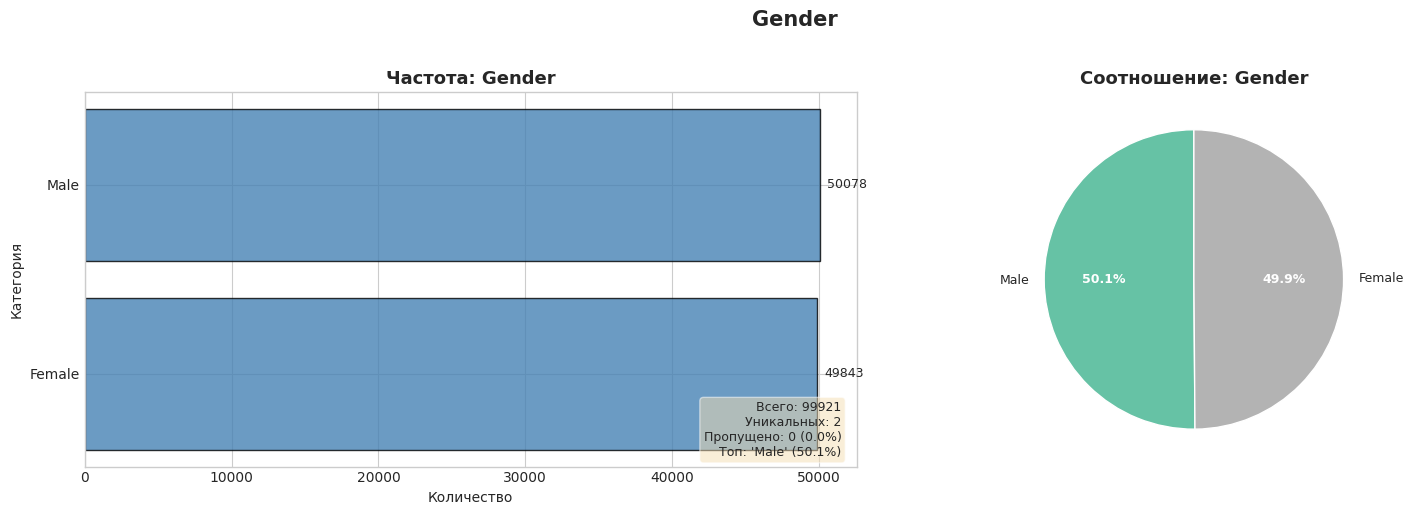

[OK] Gender:
   |- Всего значений: 99921
   |- Уникальных: 2
   |- Пропущено: 0 (0.0%)
   |- Топ 5 категорий:
      1. 'Male': 50078 (50.1%)
      2. 'Female': 49843 (49.9%)
--------------------------------------------------------------------------------


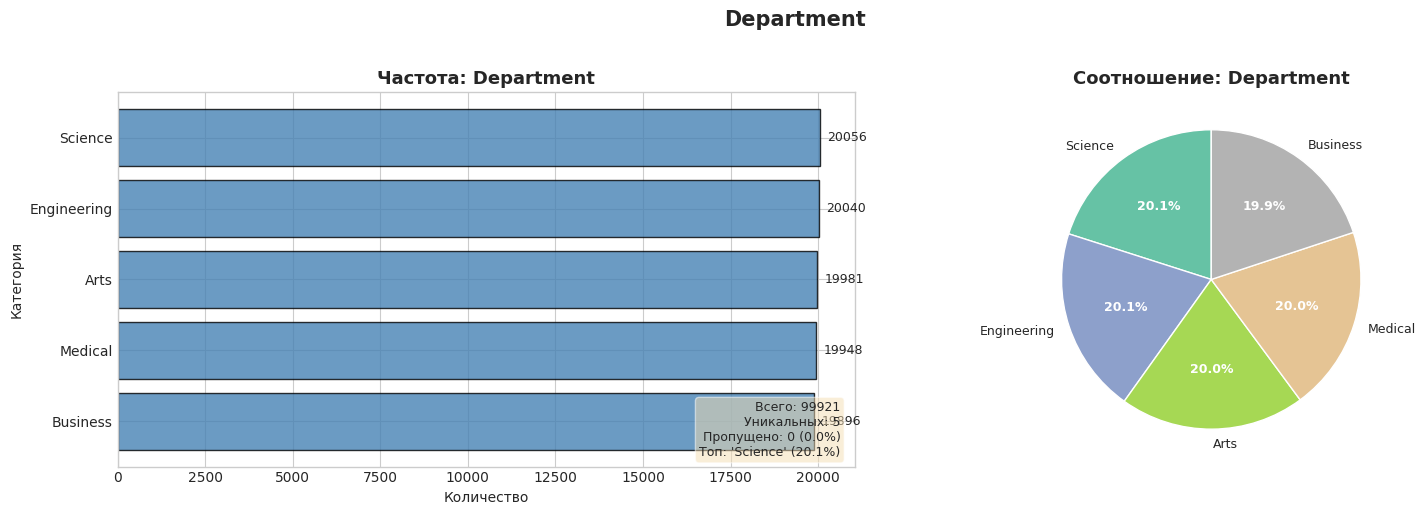

[OK] Department:
   |- Всего значений: 99921
   |- Уникальных: 5
   |- Пропущено: 0 (0.0%)
   |- Топ 5 категорий:
      1. 'Science': 20056 (20.1%)
      2. 'Engineering': 20040 (20.1%)
      3. 'Arts': 19981 (20.0%)
      4. 'Medical': 19948 (20.0%)
      5. 'Business': 19896 (19.9%)
--------------------------------------------------------------------------------


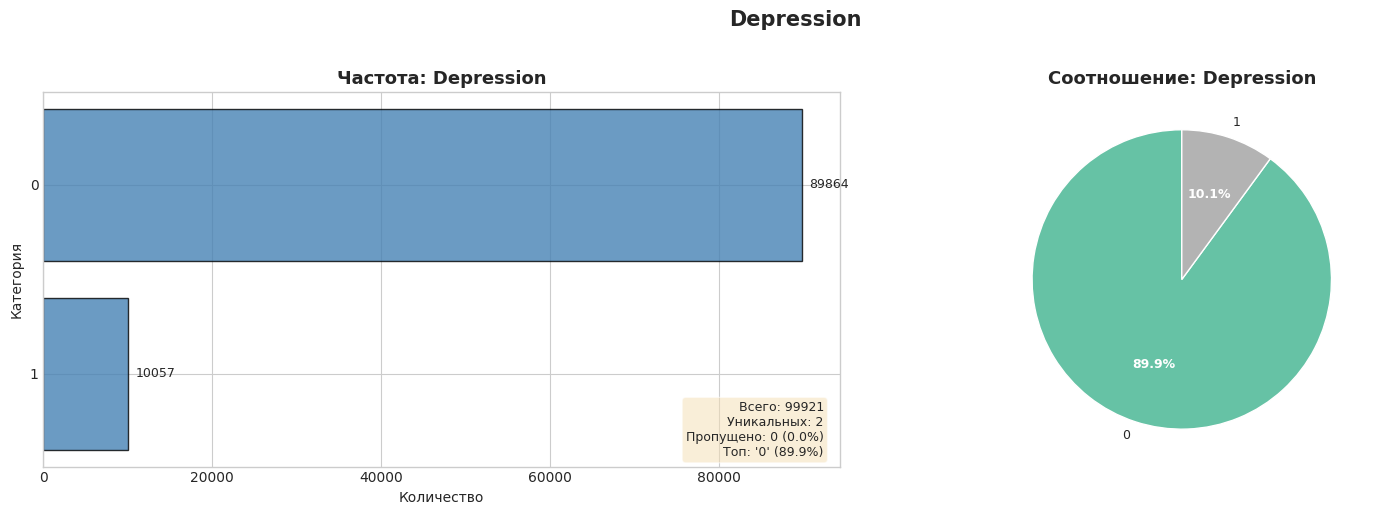

[OK] Depression:
   |- Всего значений: 99921
   |- Уникальных: 2
   |- Пропущено: 0 (0.0%)
   |- Топ 5 категорий:
      1. '0': 89864 (89.9%)
      2. '1': 10057 (10.1%)
--------------------------------------------------------------------------------


In [415]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_with_few_unique = [
    col for col in df.select_dtypes(include='number').columns
    if df[col].nunique() < 5 and df[col].nunique() > 1
]
cat_cols.extend(numeric_with_few_unique)

print(f"Найдено категориальных признаков: {len(cat_cols)}\n")

def analyze_categorical(series, feature_name, top_n=15):
    if series.nunique() == 2:
        series = series.astype(str)

    # Считаем значения, пропуски отдельно
    value_counts = series.value_counts(dropna=True)
    missing_count = series.isnull().sum()
    total_count = len(series)
    unique_count = value_counts.count()

    # Если категорий очень много — показываем только топ
    if unique_count > top_n:
        print(f"{feature_name}: {unique_count} уникальных категорий → показываем топ-{top_n}")
        value_counts = value_counts.head(top_n)
        other_count = total_count - missing_count - value_counts.sum()
    else:
        other_count = 0

    # Bar plot (абсолютные частоты)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Bar plot с горизонтальными столбцами (удобно для длинных названий)
    bars = axes[0].barh(value_counts.index[::-1], value_counts.values[::-1],
                        color='steelblue', edgecolor='black', alpha=0.8)
    axes[0].set_title(f'Частота: {feature_name}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Количество')
    axes[0].set_ylabel('Категория')

    # Подписываем значения на столбцах (если их не слишком много)
    if len(value_counts) <= 10:
        for bar in bars:
            width = bar.get_width()
            axes[0].text(width + max(value_counts.values) * 0.01,
                        bar.get_y() + bar.get_height()/2,
                        f'{int(width)}',
                        va='center', fontsize=9)

    # Pie chart с процентами (только для <= 8 категорий)
    if len(value_counts) <= 8 and other_count == 0:
        colors = plt.cm.Set2(np.linspace(0, 1, len(value_counts)))
        wedges, texts, autotexts = axes[1].pie(
            value_counts.values,
            labels=value_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=colors,
            textprops={'fontsize': 9}
        )

        # Делаем проценты читаемыми
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
        axes[1].set_title(f'Соотношение: {feature_name}', fontsize=13, fontweight='bold')

    else:
        # Если категорий много — показываем проценты в виде bar plot
        percentages = value_counts / value_counts.sum() * 100
        bars = axes[1].barh(percentages.index[::-1], percentages.values[::-1],
                           color='lightgreen', edgecolor='black', alpha=0.8)
        axes[1].set_title(f'Percentage: {feature_name}', fontsize=13, fontweight='bold')
        axes[1].set_xlabel('Percent (%)')
        axes[1].set_xlim(0, 100)

        # Подписываем проценты
        for bar in bars:
            width = bar.get_width()
            axes[1].text(width + 1, bar.get_y() + bar.get_height()/2,
                        f'{width:.1f}%', va='center', fontsize=9)

    # Статистика на графике
    stats_text = (f"Всего: {total_count}\n"
                 f"Уникальных: {unique_count}\n"
                 f"Пропущено: {missing_count} ({missing_count/total_count*100:.1f}%)\n"
                 f"Топ: '{value_counts.index[0]}' ({value_counts.values[0]/total_count*100:.1f}%)")

    if other_count > 0:
        stats_text += f"\nOther: {other_count} ({other_count/total_count*100:.1f}%)"

    axes[0].text(0.98, 0.02, stats_text, transform=axes[0].transAxes,
                 fontsize=9, verticalalignment='bottom', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle(f'{feature_name}', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Вывод в консоль
    print(f"[OK] {feature_name}:")
    print(f"   |- Всего значений: {total_count}")
    print(f"   |- Уникальных: {unique_count}")
    print(f"   |- Пропущено: {missing_count} ({missing_count/total_count*100:.1f}%)")
    print(f"   |- Топ 5 категорий:")
    for i, (cat, count) in enumerate(value_counts.head(5).items(), 1):
        pct = count / total_count * 100
        print(f"      {i}. '{cat}': {count} ({pct:.1f}%)")
    if other_count > 0:
        print(f"   |- Другие категории: {other_count} ({other_count/total_count*100:.1f}%)")
    print("-" * 80)


# Запускаем анализ для всех категориальных признаков
if not cat_cols:
    print("Категориальные признаки не найдены.")
else:
    for col in cat_cols:
        analyze_categorical(df[col], col, top_n=12)

- Категориальные признаки распределены примерно поровну
- Людей c депрессией значительно меньше, чем без

##### Числовые признаки

Найдено числовых признаков: 7



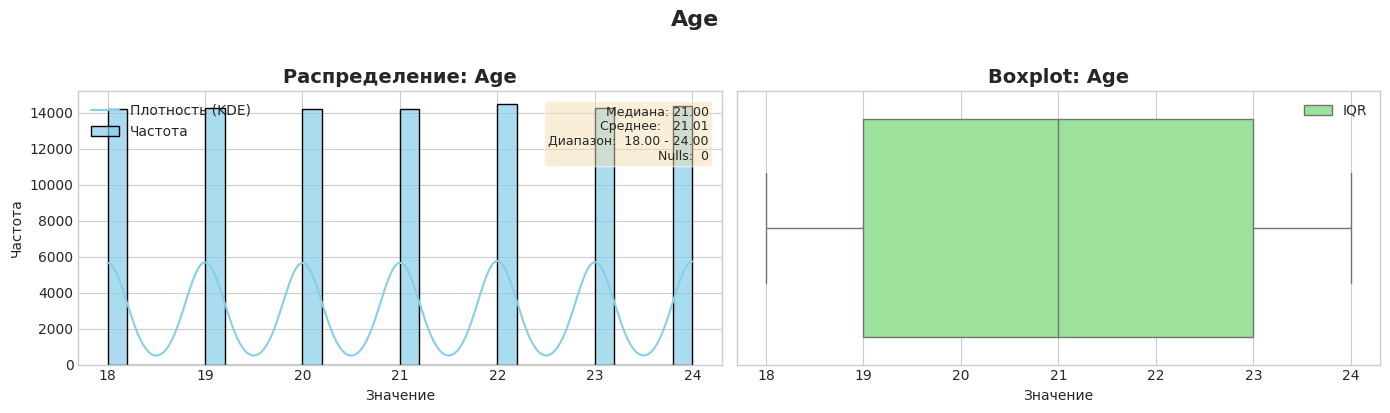

Age:
   |- Распределение: симметрично
   |- Пропущенные значения: 0
   |- Выбросы (IQR): 0
--------------------------------------------------------------------------------


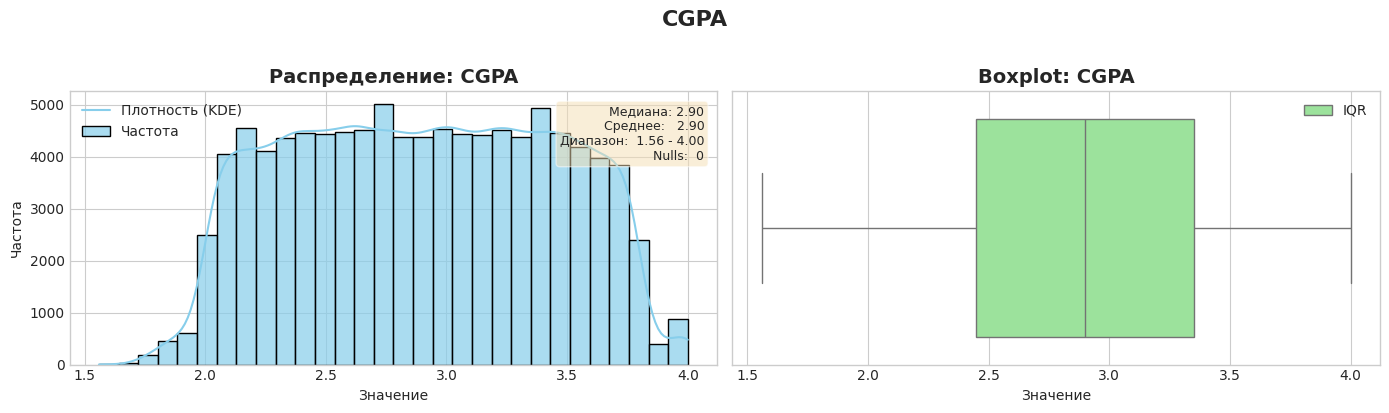

CGPA:
   |- Распределение: симметрично
   |- Пропущенные значения: 0
   |- Выбросы (IQR): 0
--------------------------------------------------------------------------------


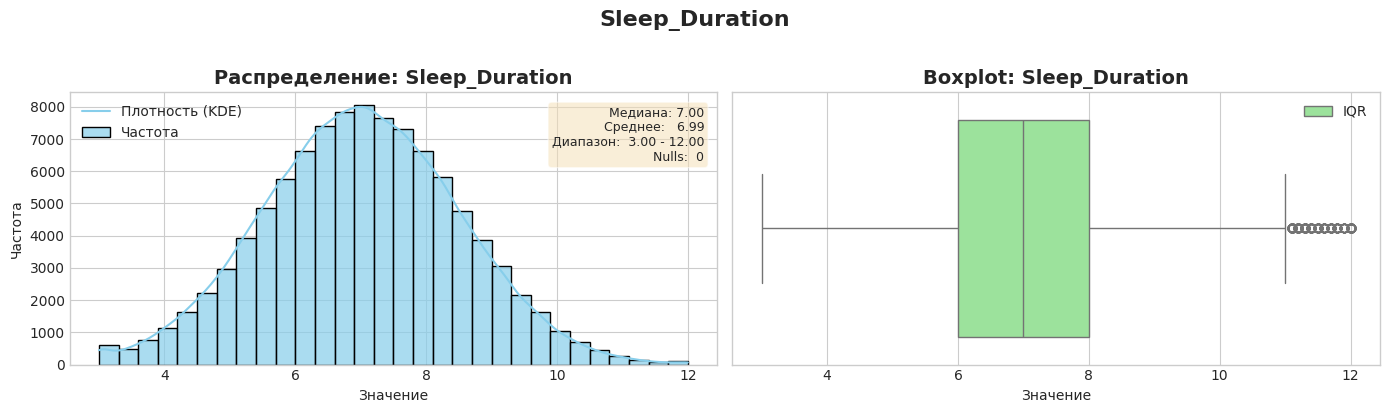

Sleep_Duration:
   |- Распределение: симметрично
   |- Пропущенные значения: 0
   |- Выбросы (IQR): 354
--------------------------------------------------------------------------------


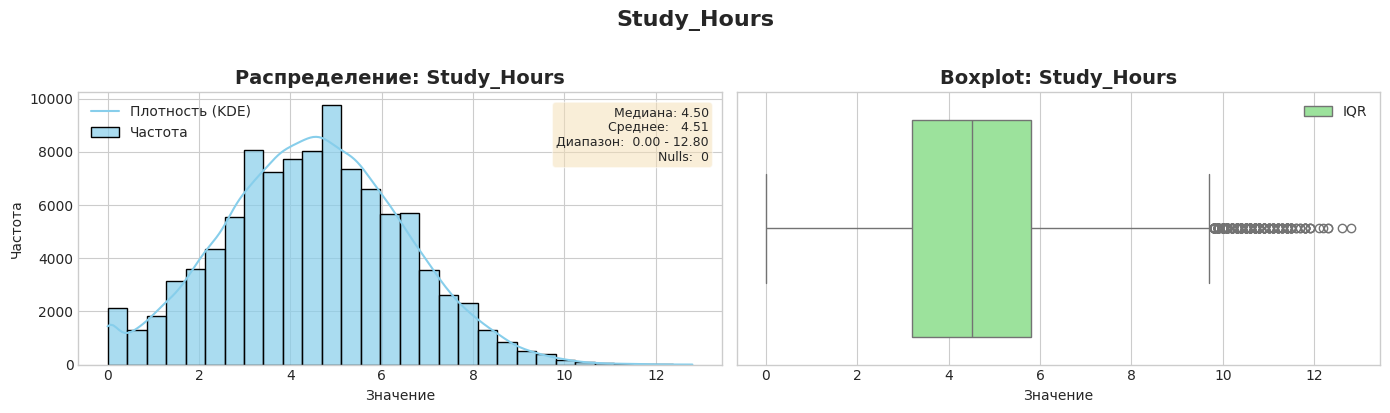

Study_Hours:
   |- Распределение: симметрично
   |- Пропущенные значения: 0
   |- Выбросы (IQR): 406
--------------------------------------------------------------------------------


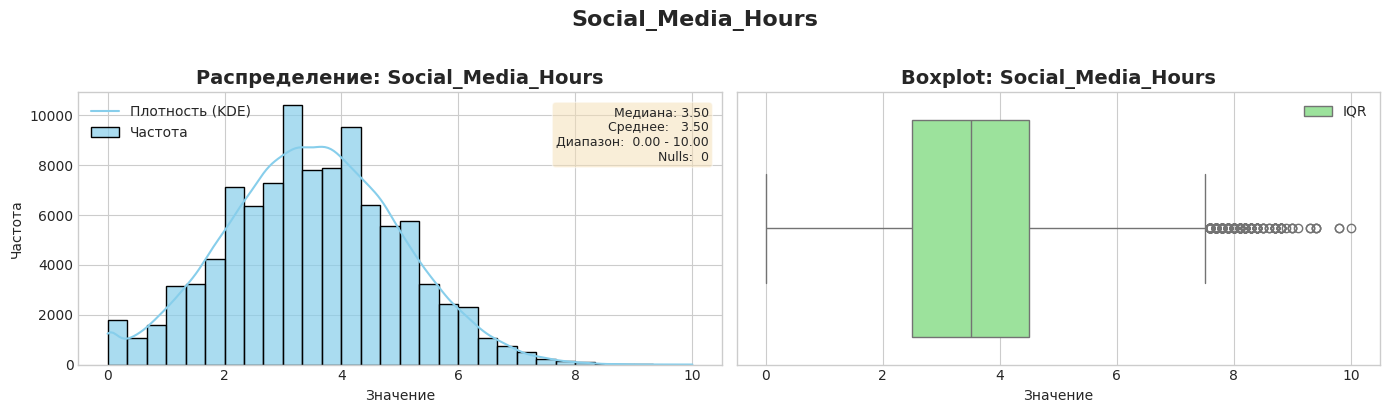

Social_Media_Hours:
   |- Распределение: симметрично
   |- Пропущенные значения: 0
   |- Выбросы (IQR): 313
--------------------------------------------------------------------------------


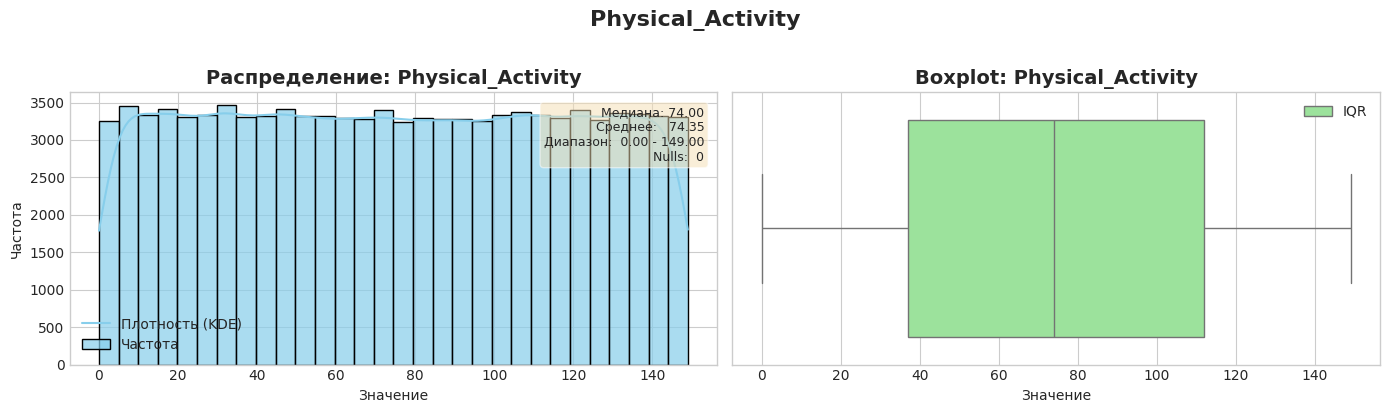

Physical_Activity:
   |- Распределение: симметрично
   |- Пропущенные значения: 0
   |- Выбросы (IQR): 0
--------------------------------------------------------------------------------


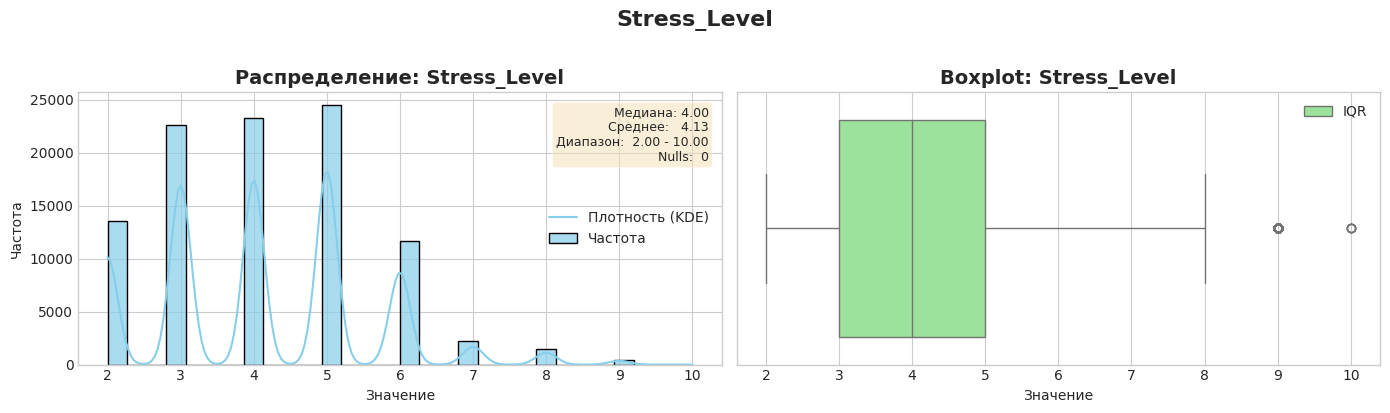

Stress_Level:
   |- Распределение: симметрично
   |- Пропущенные значения: 0
   |- Выбросы (IQR): 478
--------------------------------------------------------------------------------


In [416]:
numeric_cols = [
    col for col in df.select_dtypes(include=['number']).columns
    if df[col].nunique() >= 5
]

print(f"Найдено числовых признаков: {len(numeric_cols)}\n")

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Гистограмма + KDE
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[0],
                  color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].set_title(f'Распределение: {col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Значение')
    axes[0].set_ylabel('Частота')
    axes[0].legend(['Плотность (KDE)', 'Частота'], loc='best')

    # Boxplot
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot: {col}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Значение')
    axes[1].legend(['IQR', 'Медиана', 'Выбросы'], loc='best')

    # Статистика на графике
    stats_text = (f"Медиана: {df[col].median():.2f}\n"
                  f"Среднее:   {df[col].mean():.2f}\n"
                  f"Диапазон:  {df[col].min():.2f} - {df[col].max():.2f}\n"
                  f"Nulls:  {df[col].isnull().sum()}")

    axes[0].text(0.98, 0.95, stats_text, transform=axes[0].transAxes,
                  fontsize=9, verticalalignment='top', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle(col, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Расчет выбросов
    col_data = df[col].dropna()

    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((col_data < lower_bound) | (col_data > upper_bound)).sum()
    missing_count = df[col].isnull().sum()

    skew = col_data.skew()
    if abs(skew) < 0.5:
        skew_text = "симметрично"
    elif skew > 0:
        skew_text = "право-ассиметрично"
    else:
        skew_text = "лево-ассиметрично"

    # Вывод в консоль
    print(f"{col}:")
    print(f"   |- Распределение: {skew_text}")
    print(f"   |- Пропущенные значения: {missing_count}")
    print(f"   |- Выбросы (IQR): {outliers_count}")
    print("-" * 80)

- Распределения числовых признаков симметричные
- Небольшое количество выбросов относительно всего датасета

#### Корреляция

In [417]:
def find_strong_correlations(corr_matrix, threshold=0.7):
    """Находит пары признаков с |корреляцией| >= threshold"""
    strong_pairs = []
    columns = corr_matrix.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            corr_val = corr_matrix.iloc[i, j]

            if pd.notnull(corr_val) and abs(corr_val) >= threshold and abs(corr_val) < 0.9:
                strong_pairs.append({
                    'feature_1': columns[i],
                    'feature_2': columns[j],
                    'correlation': corr_val,
                    'strength': 'positive' if corr_val > 0 else 'negative'
                })

    if strong_pairs:
        return pd.DataFrame(strong_pairs).sort_values(
            'correlation', key=lambda x: x.abs(), ascending=False
        )
    else:
        return pd.DataFrame()

def plot_correlation_heatmap(df, method='pearson', threshold=0.7):
    """Heatmap корреляций + анализ связей"""

    numeric = df.select_dtypes(include=[np.number])

    if numeric.shape[1] < 2:
        print("Недостаточно числовых признаков для корреляции")
        return None

    corr = numeric.corr(method=method)

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": .8}
    )

    plt.title(f'Correlation Heatmap ({method})', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

    strong = find_strong_correlations(corr, threshold)

    if not strong.empty:
        print(f"\nПары с |корреляцией| >= {threshold}:")
        print(strong.to_string(index=False))
    else:
        print(f"\nКорреляций (>= {threshold}) не найдено")

    return corr

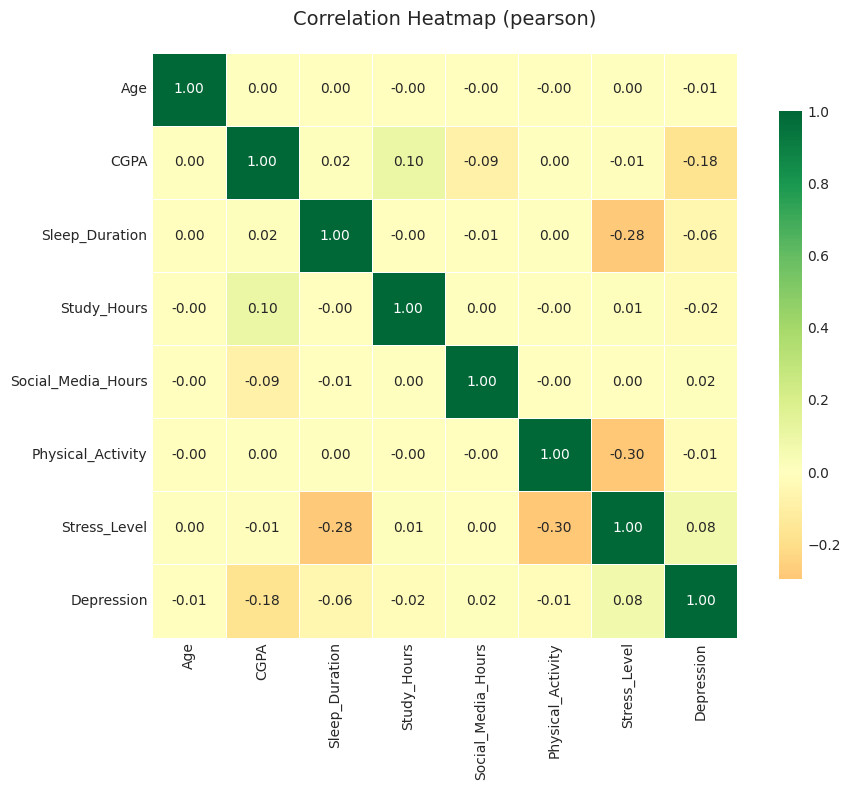


Пары с |корреляцией| >= 0.1:
        feature_1    feature_2  correlation strength
Physical_Activity Stress_Level    -0.296496 negative
   Sleep_Duration Stress_Level    -0.282099 negative
             CGPA   Depression    -0.179013 negative


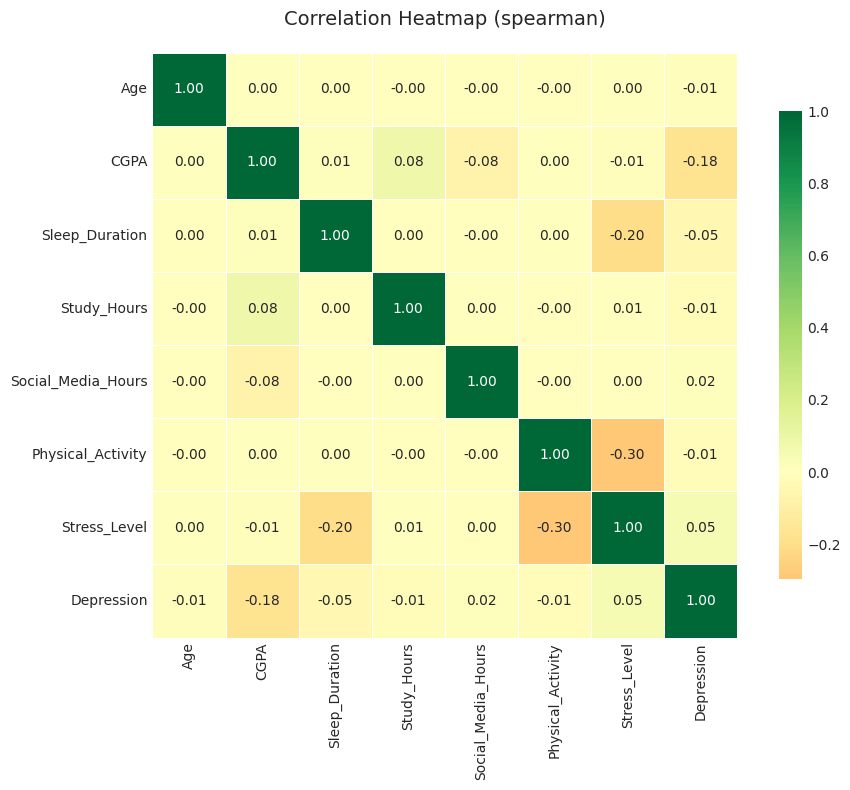


Пары с |корреляцией| >= 0.1:
        feature_1    feature_2  correlation strength
Physical_Activity Stress_Level    -0.296215 negative
   Sleep_Duration Stress_Level    -0.202314 negative
             CGPA   Depression    -0.179617 negative


In [418]:
THRESHOLD = 0.1

for method in ['pearson', 'spearman']:
    plot_correlation_heatmap(df, method=method, threshold=THRESHOLD)

- Возраст не коррелируется с другими признаками
- Большая часть корреляций сильно низкие

Выделяющиеся кореляции:
- Physical_Activity + Stress_Level: negative
- Sleep_Duration + Stress_Level: negative
- CGPA + Depression: negative

#### Влияние на таргеты категориальных признаков


##### Depression

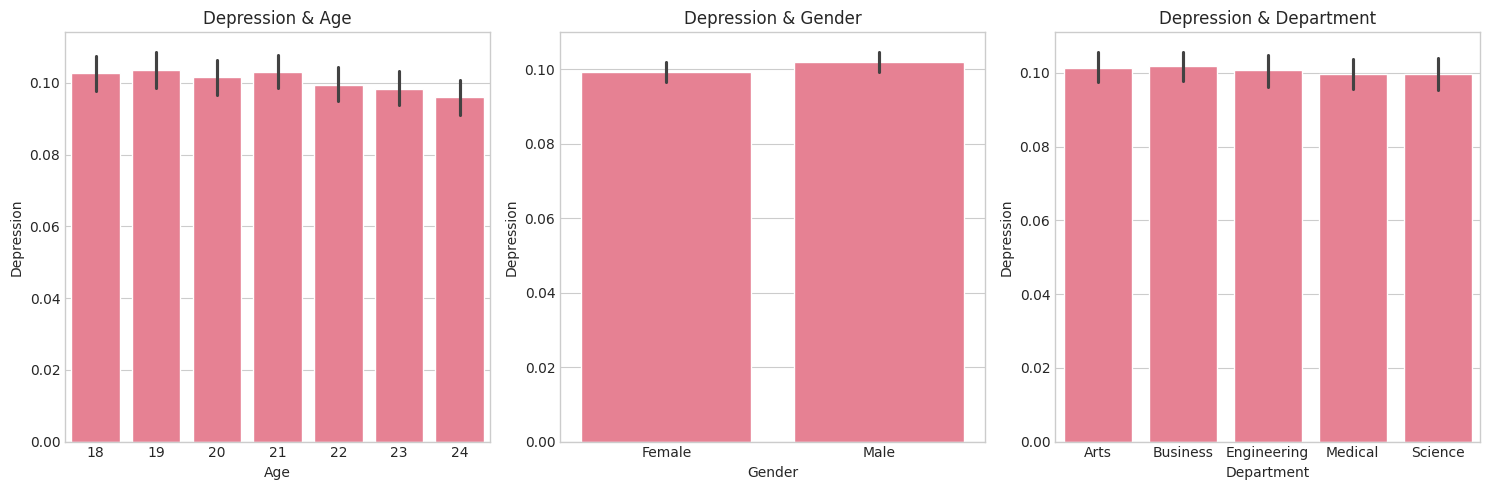

In [419]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cols = ['Age', 'Gender', 'Department']

for i, col in enumerate(cols):
    sns.barplot(data=df, x=col,y ='Depression', ax=axes[i])
    axes[i].set_title(f"Depression & {col}")

plt.tight_layout()
plt.show()

##### CGPA

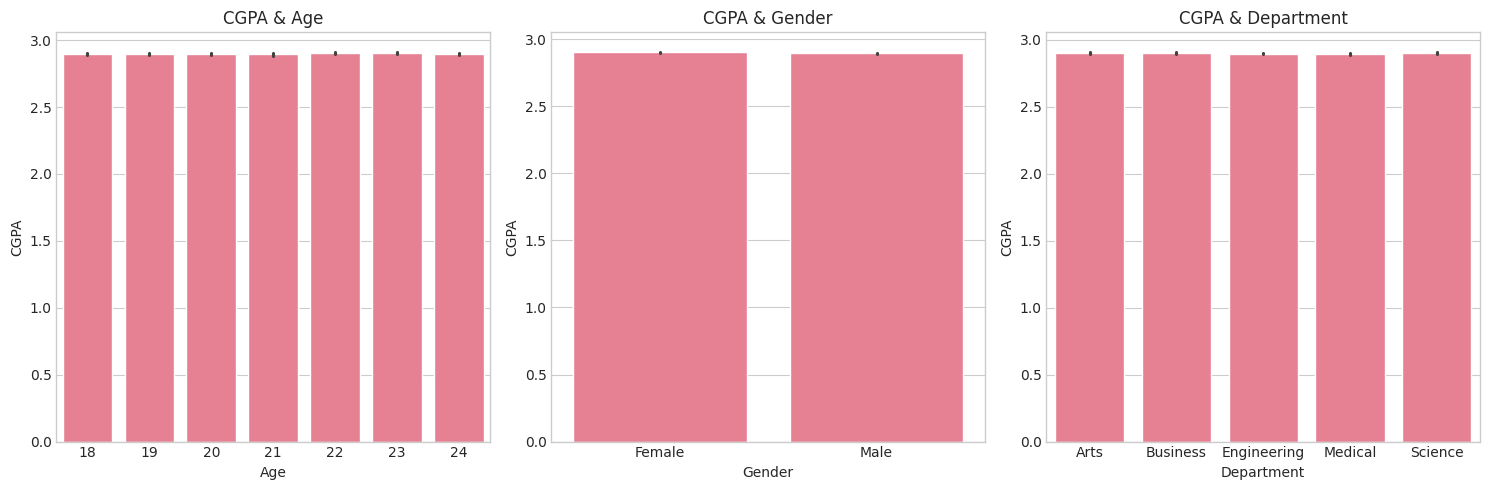

In [420]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cols = ['Age', 'Gender', 'Department']

for i, col in enumerate(cols):
    sns.barplot(data=df, x=col,y ='CGPA', ax=axes[i])
    axes[i].set_title(f"CGPA & {col}")

plt.tight_layout()
plt.show()

Влияние категориальных Age, Gender и Department на таргеты отсутствует.

Можно удалить из датафрейма.

In [421]:
df.drop(columns=['Age', 'Gender', 'Department'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99921 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CGPA                99921 non-null  float64
 1   Sleep_Duration      99921 non-null  float64
 2   Study_Hours         99921 non-null  float64
 3   Social_Media_Hours  99921 non-null  float64
 4   Physical_Activity   99921 non-null  int64  
 5   Stress_Level        99921 non-null  int64  
 6   Depression          99921 non-null  int64  
dtypes: float64(4), int64(3)
memory usage: 6.1 MB


#### Обработка выбросов


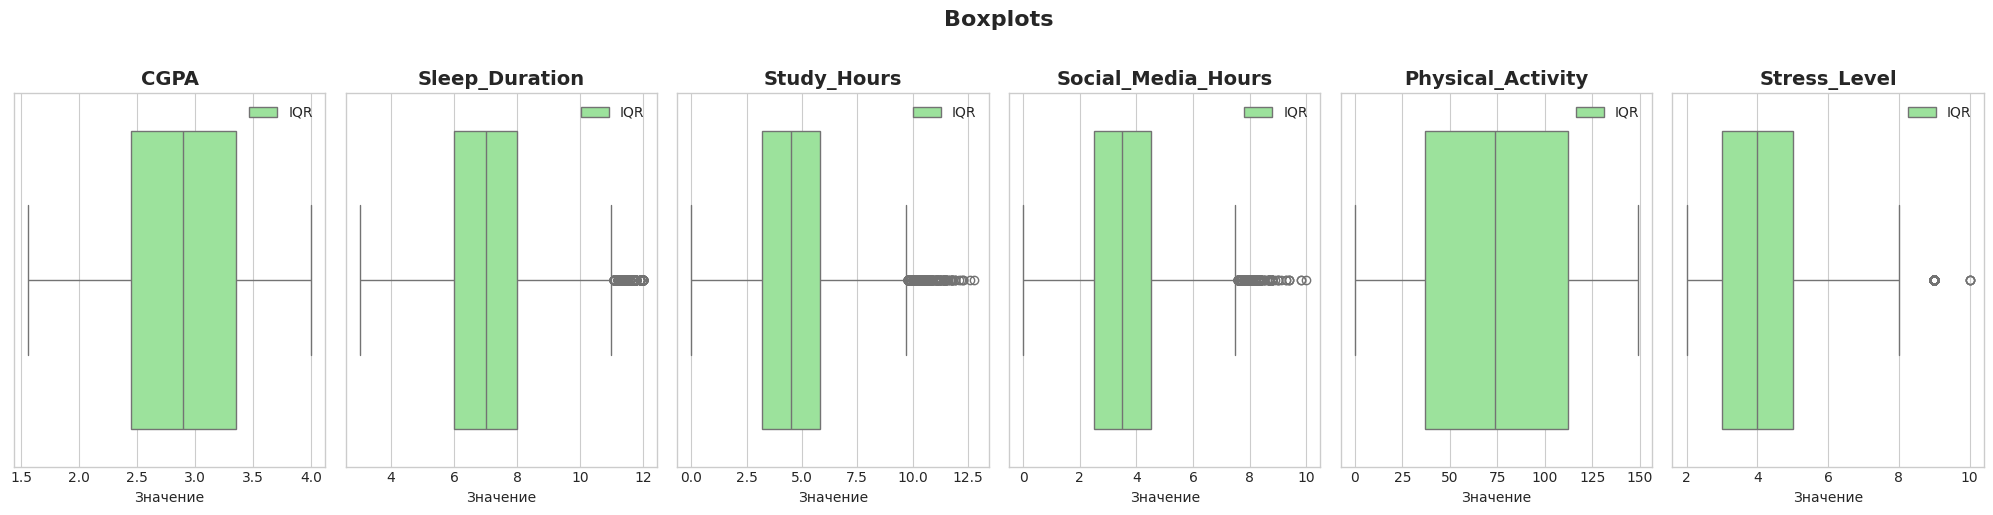

In [422]:
cols = [
    col for col in df.select_dtypes(include=['number']).columns
    if col != 'Depression'
]

fig, axes = plt.subplots(1, len(cols), figsize=(20, 5))

for i, col in enumerate(cols):
    # Boxplot
    sns.boxplot(data=df, x=col, ax=axes[i], color='lightgreen')
    axes[i].set_title(f'{col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Значение')
    axes[i].legend(['IQR', 'Медиана', 'Выбросы'], loc='best')


plt.suptitle("Boxplots", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Выбивающихся выбросов не обнаружено, все значения в рамках разумного и не одиночны, описывают краевые случаи.

Вырезание выбросов не необходимо.

#### Feature engineering

##### Новые признаки

In [423]:
df['Mental_Load'] = df['Study_Hours'] + df['Social_Media_Hours']
df['Study_Efficiency'] = df['Study_Hours'] / (df['Stress_Level'] + 1)

df['Activity_Per_Day'] = df['Physical_Activity'] / 60 / 7

Новые признаки умственной нагрузки и эффективности обучения.

Приведение активности к формату ч/сутки, как остальные временные признаки.

##### Корреляция

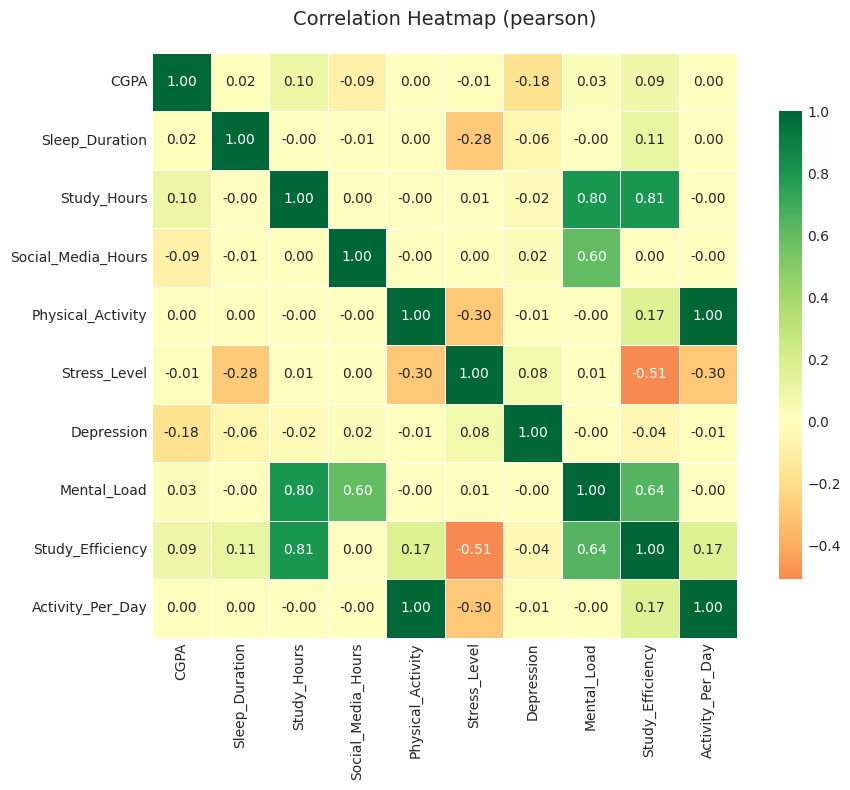


Пары с |корреляцией| >= 0.5:
         feature_1        feature_2  correlation strength
       Study_Hours Study_Efficiency     0.805041 positive
       Study_Hours      Mental_Load     0.799394 positive
       Mental_Load Study_Efficiency     0.643258 positive
Social_Media_Hours      Mental_Load     0.602703 positive
      Stress_Level Study_Efficiency    -0.509366 negative


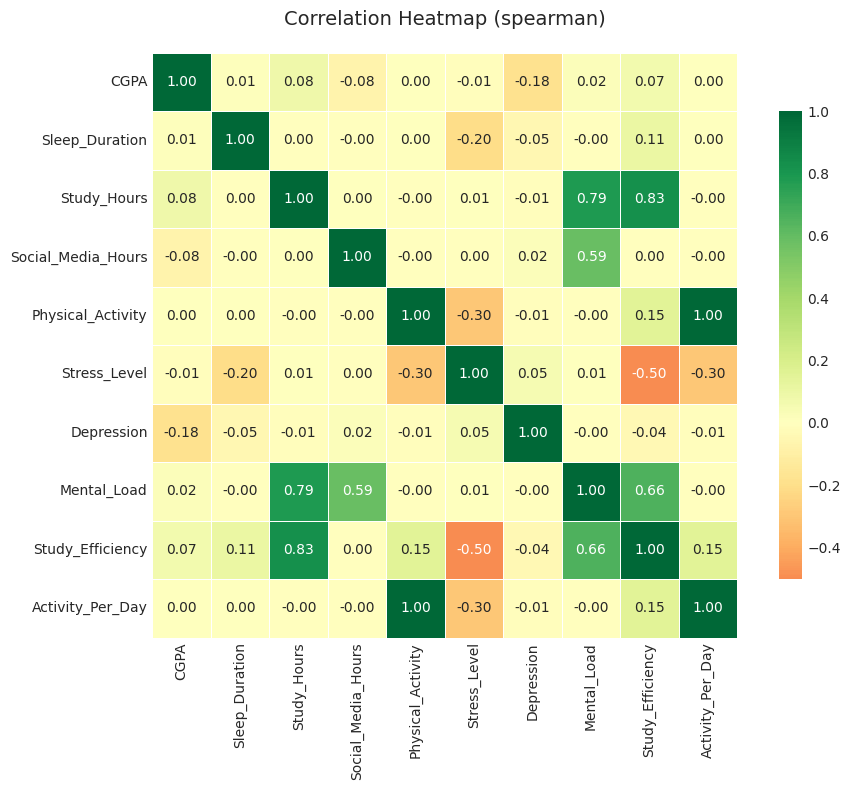


Пары с |корреляцией| >= 0.5:
         feature_1        feature_2  correlation strength
       Study_Hours Study_Efficiency     0.831272 positive
       Study_Hours      Mental_Load     0.787054 positive
       Mental_Load Study_Efficiency     0.656999 positive
Social_Media_Hours      Mental_Load     0.585806 positive
      Stress_Level Study_Efficiency    -0.501075 negative


In [424]:
THRESHOLD = 0.5

for method in ['pearson', 'spearman']:
    plot_correlation_heatmap(df, method=method, threshold=THRESHOLD)

## Линейная регрессия (CGPA)


### Обучение

In [425]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# Подготовка данных
y = df['CGPA']
X = df.drop(columns=['CGPA'])

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Обучение модели
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Прогнозы
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)


# Оценка качества модели
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    """Расчет и вывод метрик качества"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\nМетрики для {dataset_name}:")
    print(f"- MAE:  {mae:,.2f}")
    print(f"- RMSE: {rmse:,.2f}")
    print(f"- R^2:   {r2:.4f}")
    print(f"- MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}


# Оценка на обеих выборках
train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")


Метрики для Train:
- MAE:  0.44
- RMSE: 0.52
- R^2:   0.0492
- MAPE: 16.15%

Метрики для Test:
- MAE:  0.44
- RMSE: 0.52
- R^2:   0.0469
- MAPE: 16.04%


### Визуализация результатов

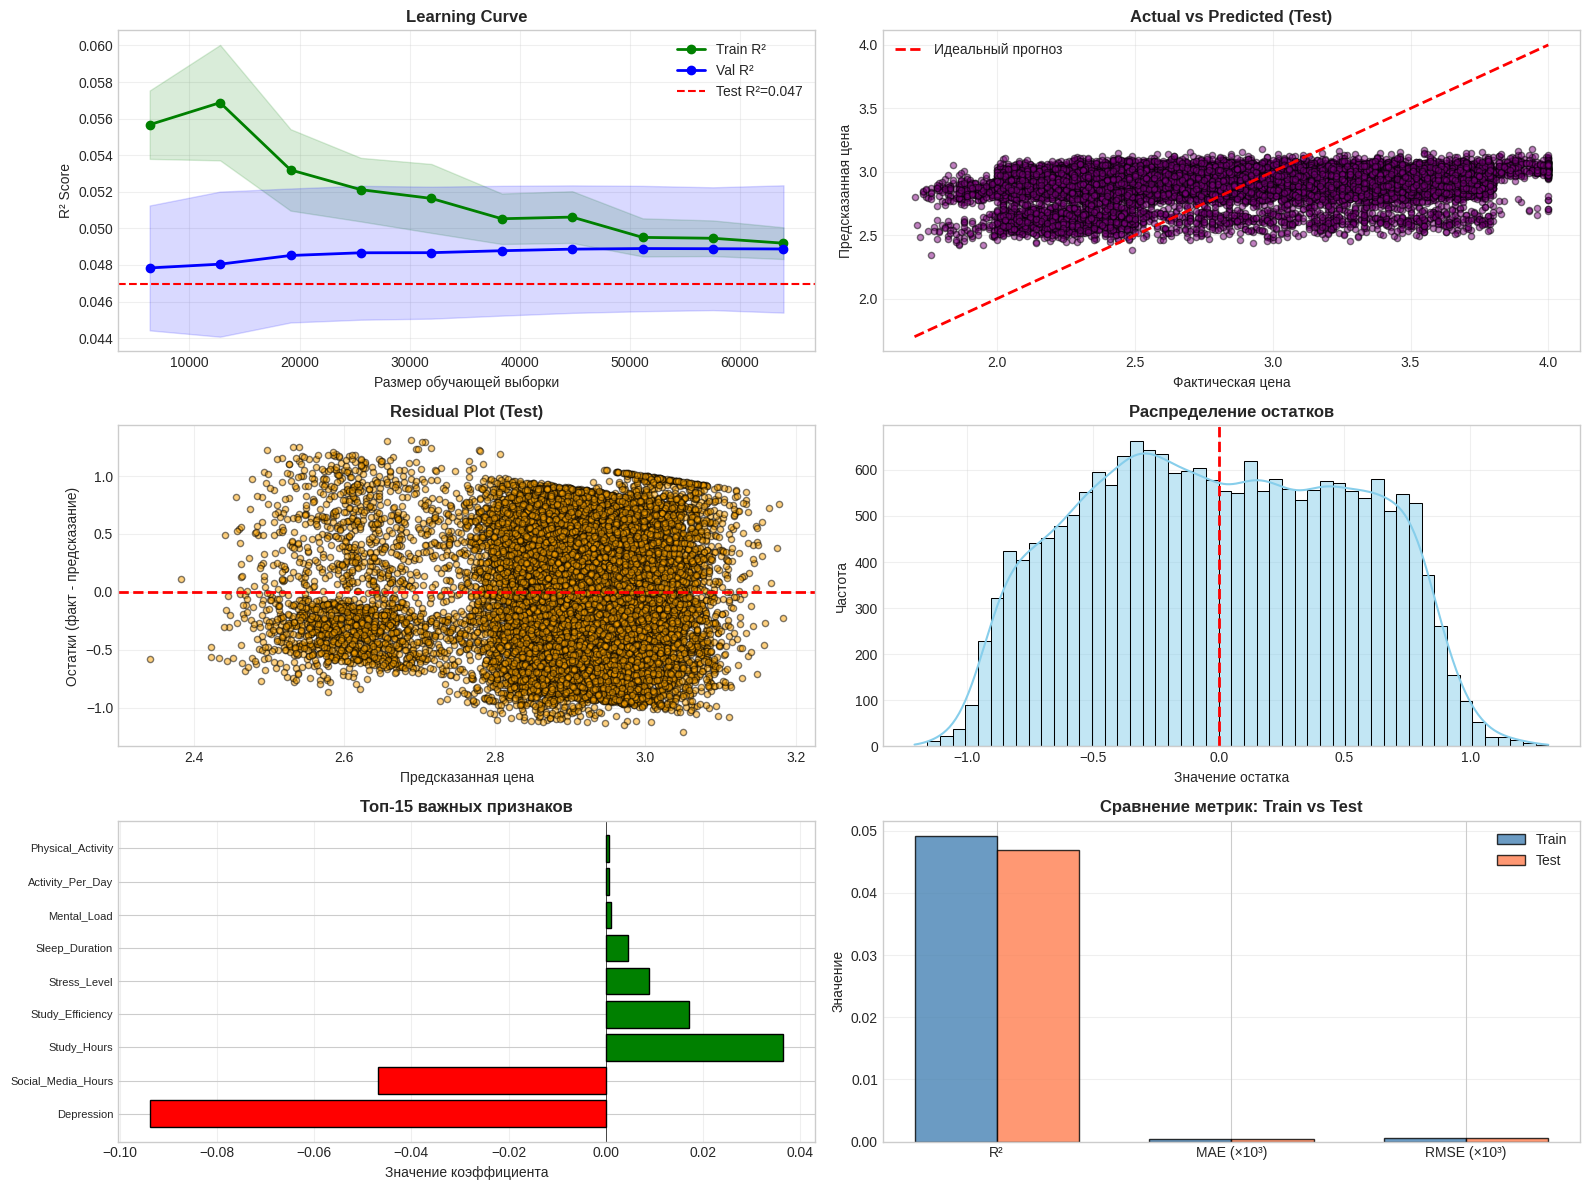

In [426]:
from sklearn.model_selection import learning_curve


plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

# Кривая обучения
ax1 = plt.subplot(3, 2, 1)
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_scaled, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

ax1.plot(train_sizes, train_mean, 'o-', color='green', label='Train R²', linewidth=2)
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='green')
ax1.plot(train_sizes, val_mean, 'o-', color='blue', label='Val R²', linewidth=2)
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')
ax1.set_xlabel('Размер обучающей выборки', fontsize=10)
ax1.set_ylabel('R² Score', fontsize=10)
ax1.set_title('Learning Curve', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=test_metrics['R2'], color='red', linestyle='--', lw=1.5, label=f'Test R²={test_metrics["R2"]:.3f}')
ax1.legend()

# Actual / Predicted
ax2 = plt.subplot(3, 2, 2)
ax2.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='black', s=20, color='purple')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальный прогноз')
ax2.set_xlabel('Фактическая цена', fontsize=10)
ax2.set_ylabel('Предсказанная цена', fontsize=10)
ax2.set_title('Actual vs Predicted (Test)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Residuals
ax3 = plt.subplot(3, 2, 3)
residuals = y_test - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.5, edgecolors='black', s=20, color='orange')
ax3.axhline(y=0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Предсказанная цена', fontsize=10)
ax3.set_ylabel('Остатки (факт - предсказание)', fontsize=10)
ax3.set_title('Residual Plot (Test)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Распределение остатков
ax4 = plt.subplot(3, 2, 4)
sns.histplot(residuals, bins=50, kde=True, ax=ax4, color='skyblue', edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', lw=2)
ax4.set_xlabel('Значение остатка', fontsize=10)
ax4.set_ylabel('Частота', fontsize=10)
ax4.set_title('Распределение остатков', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Коэффициенты модели (Топ-15 по модулю)
ax5 = plt.subplot(3, 2, 5)
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_
})
coefficients = coefficients.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False).head(15)

colors = ['green' if c > 0 else 'red' for c in coefficients['coef']]
bars = ax5.barh(coefficients['feature'], coefficients['coef'], color=colors, edgecolor='black')
ax5.set_xlabel('Значение коэффициента', fontsize=10)
ax5.set_title('Топ-15 важных признаков', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')
ax5.axvline(x=0, color='black', lw=0.5)
plt.setp(ax5.get_yticklabels(), fontsize=8)

# Сравнение метрик Train/Test
ax6 = plt.subplot(3, 2, 6)
metrics_names = ['R²', 'MAE', 'RMSE']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics['R2'], train_metrics['MAE']/1000, train_metrics['RMSE']/1000]
test_vals = [test_metrics['R2'], test_metrics['MAE']/1000, test_metrics['RMSE']/1000]

ax6.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax6.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(['R²', 'MAE (×10³)', 'RMSE (×10³)'])
ax6.set_ylabel('Значение', fontsize=10)
ax6.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('linear_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()

### Дополнительная диагностика

In [427]:
# Проверка на переобучение
r2_diff = train_metrics['R2'] - test_metrics['R2']
print(f"Разница R^2 (Train - Test): {r2_diff:.4f}")
if r2_diff > 0.1:
    print("  > Возможное переобучение.")
elif r2_diff < -0.1:
    print("  > Тест лучше трейна. Проверьте разделение данных.")
else:
    print("  > Модель обобщает данные адекватно.")

# Факторы влияния на CGPA
print(f"\nТоп факторов, увеличивающих CGPA:")
top_positive = coefficients[coefficients['coef'] > 0].head(10)
for _, row in top_positive.iterrows():
    print(f"  + {row['feature']}: {row['coef']:.2f}")

print(f"\nТоп факторов, уменьшающих CGPA:")
top_negative = coefficients[coefficients['coef'] < 0].head(10)
for _, row in top_negative.iterrows():
    print(f"  - {row['feature']}: {row['coef']:.2f}")

Разница R^2 (Train - Test): 0.0022
  > Модель обобщает данные адекватно.

Топ факторов, увеличивающих CGPA:
  + Study_Hours: 0.04
  + Study_Efficiency: 0.02
  + Stress_Level: 0.01
  + Sleep_Duration: 0.00
  + Mental_Load: 0.00
  + Activity_Per_Day: 0.00
  + Physical_Activity: 0.00

Топ факторов, уменьшающих CGPA:
  - Depression: -0.09
  - Social_Media_Hours: -0.05


### Метрики

<!-- Метрики для Train:
> MAE:  0.44
> RMSE: 0.52
> R^2:   0.0492
> MAPE: 16.15%

Метрики для Test:
> MAE:  0.44
> RMSE: 0.52
> R^2:   0.0469
> MAPE: 16.04% -->

- **MAE** - средняя абсолютная ошибка. Модель ошибается в среднем на 0.44 балла CGPA
- **RMSE** - среднеквадратичная ошибка с усиленным штрафом за большие отклонения. В среднем 0.52, что близко к MAE. Следовательно, нет сильных выбросов.
- **R^2** - доля объяснённой вариации. Метрика примерно 0.05, т.е. модель объясняет всего 5% вариаций CGPA.
- **MAPE** - средняя ошибка в процентах. Модель ошибается примерно на 16%.


### Заключение

Метрики train и test выборок практически совпадают, значит, модель точно не переобучена.

Зависимость таргета от признаков слабая, поэтому предсказания чаще опираются на среднее значение, чем на реальные признаки.

## Логистическая регрессия (Depression)

### Обучение

In [428]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler


class LogisticRegressionCustom:
    """
    Логистическая регрессия с градиентным спуском.
    Функция активации: Сигмоида
    Функция потерь: Binary Cross-Entropy (Log Loss)
    """
    def __init__(self, learning_rate=0.01, n_iterations=100, random_state=42, penalty='l2', alpha=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.penalty = penalty  # 'l2' или None
        self.alpha = alpha      # Коэффициент регуляризации
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _initialize_parameters(self, n_features):
        """Инициализация весов и смещения"""
        np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

    def _sigmoid(self, z):
        """Сигмоидная функция активации"""
        z = np.clip(z, -500, 500)  # Предотвращение переполнения
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred_proba):
        """Вычисление Binary Cross-Entropy Loss"""
        epsilon = 1e-15  # Для предотвращения log(0)
        y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)

        loss = -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))

        # Добавляем L2 регуляризацию к лоссу
        if self.penalty == 'l2':
            loss += (self.alpha / (2 * len(y_true))) * np.sum(self.weights ** 2)

        return loss

    def fit(self, X, y):
        """Обучение модели градиентным спуском"""
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        self.loss_history = []

        for epoch in range(self.n_iterations):
            # Прямой проход
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred_proba = self._sigmoid(linear_output)

            # Вычисление ошибки (Log Loss)
            loss = self._compute_loss(y, y_pred_proba)
            self.loss_history.append(loss)

            # Обратный проход - вычисление градиентов
            error = y_pred_proba - y  # Производная Cross-Entropy + Sigmoid

            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            # Градиент регуляризации
            if self.penalty == 'l2':
                dw += (self.alpha / n_samples) * self.weights

            # Обновление весов
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        """Вероятность принадлежности к классу 1"""
        linear_output = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_output)

    def predict(self, X, threshold=0.5):
        """Предсказание класса (0 или 1)"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

    def score(self, X, y):
        """Точность модели"""
        predictions = self.predict(X)
        return accuracy_score(y, predictions)


y = df['Depression']
X = df.drop(columns=['Depression'])

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Параметры обучения
n_epochs = 100
learning_rate = 0.1

# Обучение модели
model = LogisticRegressionCustom(
    learning_rate=learning_rate,
    n_iterations=n_epochs,
    random_state=42,
    penalty='l2',  # L2 регуляризация для предотвращения переобучения
    alpha=0.01
)
model.fit(X_train_scaled, y_train)

# Прогнозы
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)


# Оценка качества модели
def evaluate_classification(y_true, y_pred, y_proba=None, dataset_name="Dataset"):
    """Расчет и вывод метрик классификации"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    print(f"\nМетрики для {dataset_name}:")
    print(f"- Accuracy:  {accuracy:.4f}")
    print(f"- Precision: {precision:.4f}")
    print(f"- Recall:    {recall:.4f}")
    print(f"- F1-Score:  {f1:.4f}")
    if auc_roc:
        print(f"- AUC-ROC:   {auc_roc:.4f}")

    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}

# Оценка на выборках
train_metrics = evaluate_classification(y_train, y_train_pred, dataset_name="Train")
test_metrics = evaluate_classification(y_test, y_test_pred, y_proba=y_test_proba, dataset_name="Test")


Метрики для Train:
- Accuracy:  0.8993
- Precision: 0.0000
- Recall:    0.0000
- F1-Score:  0.0000

Метрики для Test:
- Accuracy:  0.8994
- Precision: 0.0000
- Recall:    0.0000
- F1-Score:  0.0000
- AUC-ROC:   0.6858


### Визуализация результатов


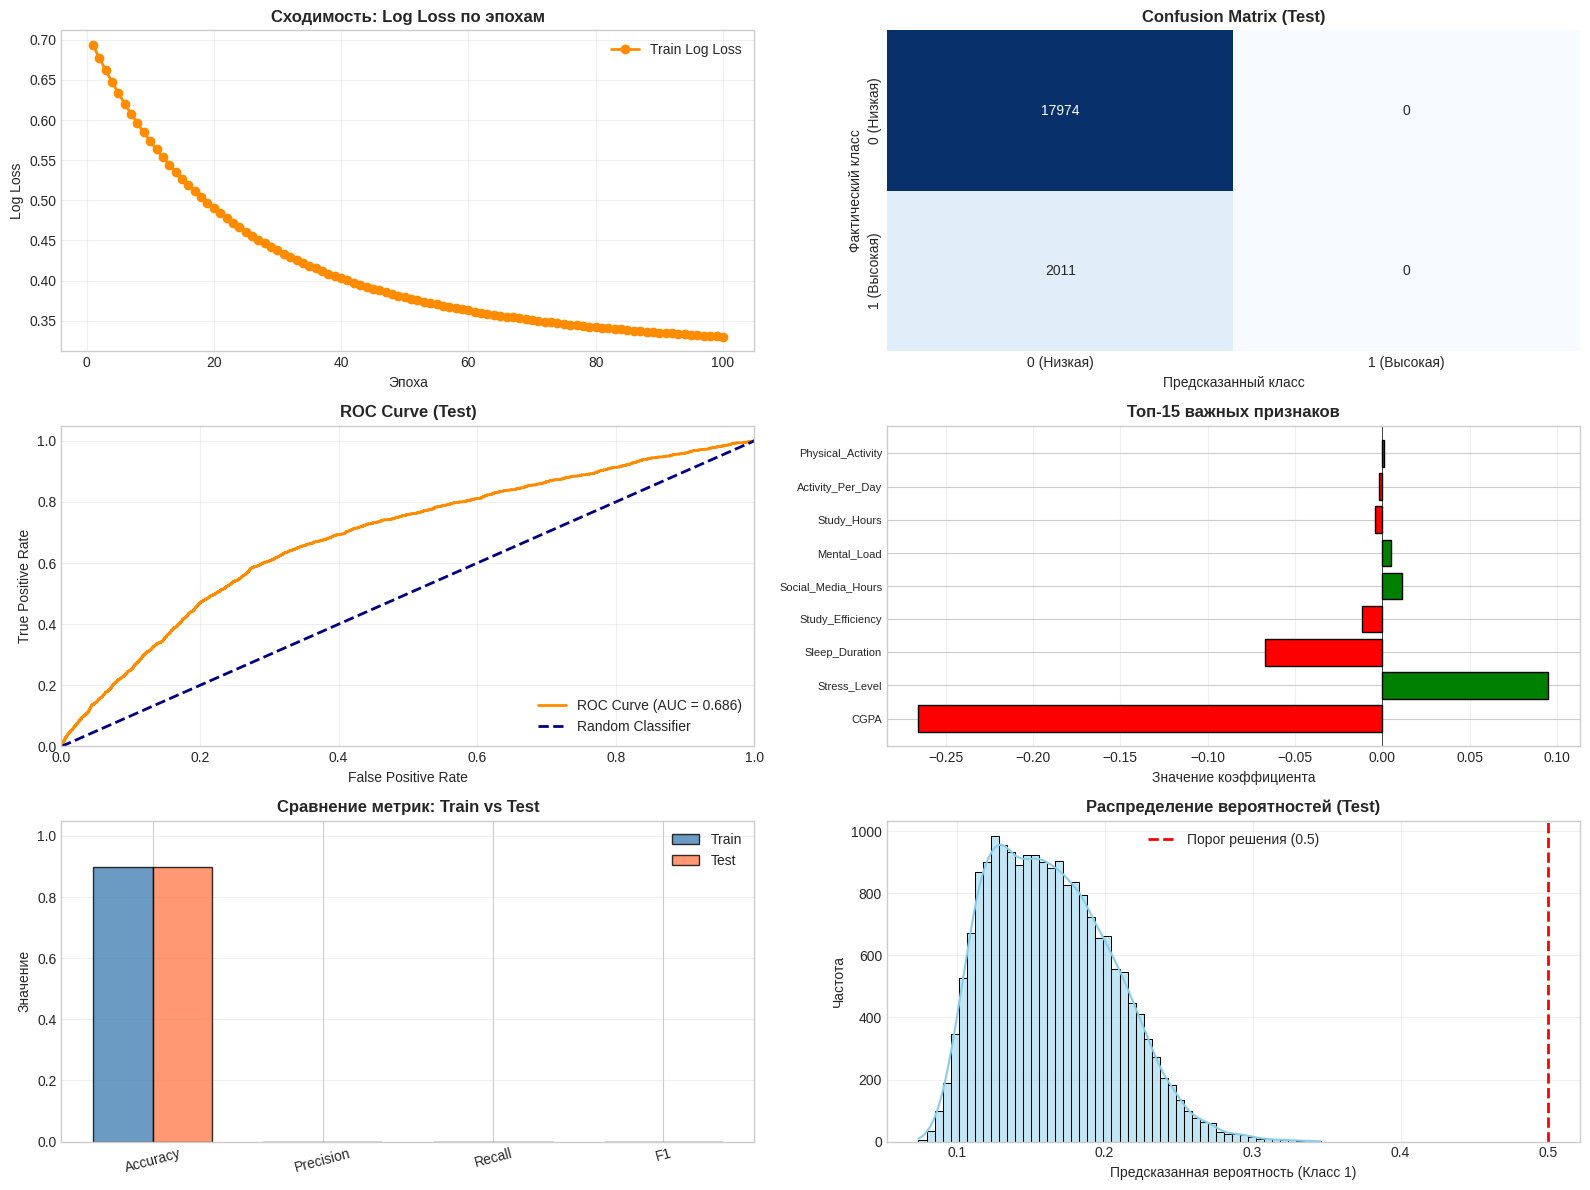

In [429]:
  plt.style.use('seaborn-v0_8-whitegrid')
  fig = plt.figure(figsize=(16, 12))

  # Loss History (Log Loss по эпохам)
  ax1 = plt.subplot(3, 2, 1)
  ax1.plot(range(1, n_epochs + 1), model.loss_history, 'o-', color='darkorange', linewidth=2, label='Train Log Loss')
  ax1.set_xlabel('Эпоха', fontsize=10)
  ax1.set_ylabel('Log Loss', fontsize=10)
  ax1.set_title('Сходимость: Log Loss по эпохам', fontsize=12, fontweight='bold')
  ax1.legend(loc='upper right')
  ax1.grid(True, alpha=0.3)

  # Confusion Matrix (Test)
  ax2 = plt.subplot(3, 2, 2)
  cm = confusion_matrix(y_test, y_test_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
  ax2.set_xlabel('Предсказанный класс', fontsize=10)
  ax2.set_ylabel('Фактический класс', fontsize=10)
  ax2.set_title('Confusion Matrix (Test)', fontsize=12, fontweight='bold')
  ax2.set_xticklabels(['0 (Низкая)', '1 (Высокая)'])
  ax2.set_yticklabels(['0 (Низкая)', '1 (Высокая)'])

  # ROC Curve
  ax3 = plt.subplot(3, 2, 3)
  fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
  ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_metrics["AUC-ROC"]:.3f})')
  ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
  ax3.set_xlim([0.0, 1.0])
  ax3.set_ylim([0.0, 1.05])
  ax3.set_xlabel('False Positive Rate', fontsize=10)
  ax3.set_ylabel('True Positive Rate', fontsize=10)
  ax3.set_title('ROC Curve (Test)', fontsize=12, fontweight='bold')
  ax3.legend(loc="lower right")
  ax3.grid(True, alpha=0.3)

  # Распределение весов модели (Топ-15)
  ax4 = plt.subplot(3, 2, 4)
  weights_df = pd.DataFrame({
      'feature': X.columns,
      'weight': model.weights
  })
  weights_df = weights_df.sort_values(by='weight', key=lambda x: np.abs(x), ascending=False).head(15)

  colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
  bars = ax4.barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
  ax4.set_xlabel('Значение коэффициента', fontsize=10)
  ax4.set_title('Топ-15 важных признаков', fontsize=12, fontweight='bold')
  ax4.grid(True, alpha=0.3, axis='x')
  ax4.axvline(x=0, color='black', lw=0.5)
  plt.setp(ax4.get_yticklabels(), fontsize=8)

  # Сравнение метрик Train/Test
  ax5 = plt.subplot(3, 2, 5)
  metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
  x_pos = np.arange(len(metrics_names))
  width = 0.35

  train_vals = [train_metrics['Accuracy'], train_metrics['Precision'], train_metrics['Recall'], train_metrics['F1']]
  test_vals = [test_metrics['Accuracy'], test_metrics['Precision'], test_metrics['Recall'], test_metrics['F1']]

  ax5.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
  ax5.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
  ax5.set_xticks(x_pos)
  ax5.set_xticklabels(metrics_names, rotation=15)
  ax5.set_ylabel('Значение', fontsize=10)
  ax5.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
  ax5.set_ylim(0, 1.05)
  ax5.legend()
  ax5.grid(True, alpha=0.3, axis='y')

  # Распределение предсказанных вероятностей
  ax6 = plt.subplot(3, 2, 6)
  sns.histplot(y_test_proba, bins=50, kde=True, ax=ax6, color='skyblue', edgecolor='black')
  ax6.axvline(x=0.5, color='red', linestyle='--', lw=2, label='Порог решения (0.5)')
  ax6.set_xlabel('Предсказанная вероятность (Класс 1)', fontsize=10)
  ax6.set_ylabel('Частота', fontsize=10)
  ax6.set_title('Распределение вероятностей (Test)', fontsize=12, fontweight='bold')
  ax6.legend()
  ax6.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.savefig('logistic_regression_results.png', dpi=300, bbox_inches='tight')
  plt.show()

### Дополнительная диагностика

In [430]:
print(f"\nДиагностика Логистической Регрессии:")
print(f"  Количество эпох: {n_epochs}")
print(f"  Learning Rate: {learning_rate}")
print(f"  Регуляризация: {model.penalty} (alpha={model.alpha})")
print(f"  Initial Loss: {model.loss_history[0]:.4f}")
print(f"  Final Loss: {model.loss_history[-1]:.4f}")

# Проверка сходимости
loss_reduction = (model.loss_history[0] - model.loss_history[-1]) / model.loss_history[0] * 100
if loss_reduction > 50:
    print(f"\nХорошая сходимость: Loss снизился на {loss_reduction:.1f}%")
elif loss_reduction > 10:
    print(f"\nУмеренная сходимость: Loss снизился на {loss_reduction:.1f}%")
else:
    print(f"\nПлохая сходимость: Loss снизился только на {loss_reduction:.1f}%")
    print("Попробуйте увеличить learning_rate или количество эпох")

# Проверка на переобучение
acc_diff = train_metrics['Accuracy'] - test_metrics['Accuracy']
if acc_diff > 0.1:
    print("\nВозможное переобучение. Разница Accuracy > 10%")
elif acc_diff < -0.05:
    print("\nТест лучше трейна.")
else:
    print("\nМодель обобщает данные адекватно.")

# Топ-10 положительных и отрицательных коэффициентов
print(f"\nТоп признаков, увеличивающих вероятность депрессии:")
top_positive = weights_df[weights_df['weight'] > 0].head(10)
for _, row in top_positive.iterrows():
    print(f"  + {row['feature']}: {row['weight']:.4f}")

print(f"\nТоп признаков, уменьшающих вероятность депрессии:")
top_negative = weights_df[weights_df['weight'] < 0].head(10)
for _, row in top_negative.iterrows():
    print(f"  - {row['feature']}: {row['weight']:.4f}")


# Анализ порогового значения (Threshold)
print("\nАнализ оптимального порога классификации:")
thresholds_to_check = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
best_f1 = 0
best_threshold = 0.5

for thresh in thresholds_to_check:
    y_pred_custom = (y_test_proba >= thresh).astype(int)
    f1_curr = f1_score(y_test, y_pred_custom)
    acc_curr = accuracy_score(y_test, y_pred_custom)
    print(f"  Порог {thresh}: Accuracy={acc_curr:.3f}, F1={f1_curr:.3f}")

    if f1_curr > best_f1:
        best_f1 = f1_curr
        best_threshold = thresh

print(f"\nОптимальный порог: {best_threshold} (F1={best_f1:.3f})")


Диагностика Логистической Регрессии:
  Количество эпох: 100
  Learning Rate: 0.1
  Регуляризация: l2 (alpha=0.01)
  Initial Loss: 0.6936
  Final Loss: 0.3301

Хорошая сходимость: Loss снизился на 52.4%

Модель обобщает данные адекватно.

Топ признаков, увеличивающих вероятность депрессии:
  + Stress_Level: 0.0951
  + Social_Media_Hours: 0.0115
  + Mental_Load: 0.0052
  + Physical_Activity: 0.0007

Топ признаков, уменьшающих вероятность депрессии:
  - CGPA: -0.2655
  - Sleep_Duration: -0.0672
  - Study_Efficiency: -0.0119
  - Study_Hours: -0.0040
  - Activity_Per_Day: -0.0017

Анализ оптимального порога классификации:
  Порог 0.1: Accuracy=0.127, F1=0.186
  Порог 0.2: Accuracy=0.780, F1=0.280
  Порог 0.3: Accuracy=0.899, F1=0.016
  Порог 0.4: Accuracy=0.899, F1=0.000
  Порог 0.5: Accuracy=0.899, F1=0.000
  Порог 0.6: Accuracy=0.899, F1=0.000
  Порог 0.7: Accuracy=0.899, F1=0.000
  Порог 0.8: Accuracy=0.899, F1=0.000
  Порог 0.9: Accuracy=0.899, F1=0.000

Оптимальный порог: 0.2 (F1=0.28

### Анализ

- Recall (нахождение реальных случаев) равен 0, т.е. модель совсем не обнаруживает людей с депрессией
- Accuracy (доля правильных ответов) состовляет около 0.9 при разных порогах. Модель предсказывает всем пользователем отсутсвие депрессии и попадает в 90% случаев, т.к. признак не сбалансирован.
- Метрики на train и test выборках совпадают, следовательно, модель не переобучена.


Несмотря на высокую accuracy, модель не выявляет случаи депрессии, что связано с дисбалансом классов и слабой зависимостью таргета от признаков.

Для улучшения качества классификации требуется изменение порога принятия решения или применение методов балансировки класса Depression.


### Эксперимент

Заменим порог принятия решения на оптимальный 0.2

In [431]:
threshold = 0.2

# Вероятности
y_train_proba_new = model.predict_proba(X_train_scaled)
y_test_proba_new = model.predict_proba(X_test_scaled)

# Новые предсказания с порогом 0.2
y_train_pred_new = (y_train_proba_new >= threshold).astype(int)
y_test_pred_new = (y_test_proba_new >= threshold).astype(int)

# Метрики
train_metrics_new = evaluate_classification(y_train, y_train_pred_new, dataset_name="Train")
test_metrics_new = evaluate_classification(y_test, y_test_pred_new, y_proba=y_test_proba_new, dataset_name="Test")


Метрики для Train:
- Accuracy:  0.7798
- Precision: 0.2102
- Recall:    0.4304
- F1-Score:  0.2824

Метрики для Test:
- Accuracy:  0.7800
- Precision: 0.2086
- Recall:    0.4247
- F1-Score:  0.2798
- AUC-ROC:   0.6858


#### Визуализация

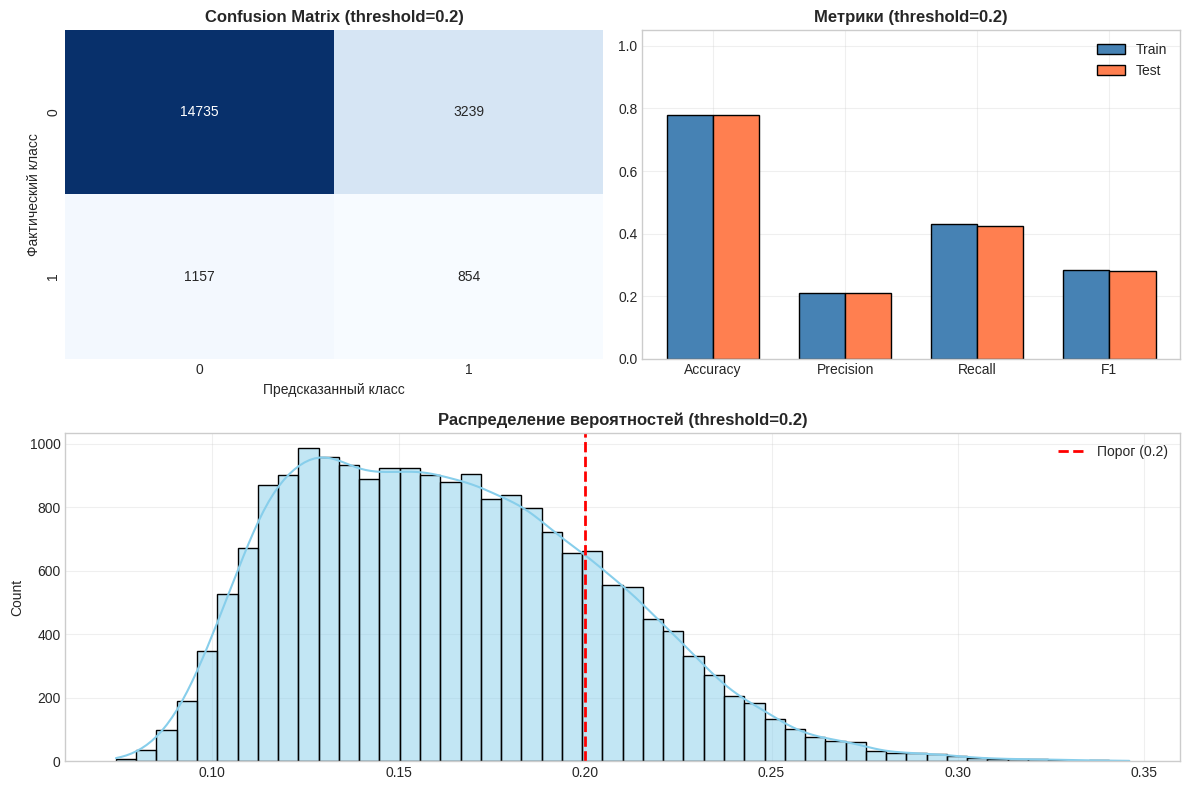

In [432]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(12, 8))

# Confusion Matrix (Test)
ax1 = plt.subplot(2, 2, 1)
cm = confusion_matrix(y_test, y_test_pred_new)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
ax1.set_xlabel('Предсказанный класс', fontsize=10)
ax1.set_ylabel('Фактический класс', fontsize=10)
ax1.set_title('Confusion Matrix (threshold=0.2)', fontsize=12, fontweight='bold')
ax1.set_xticklabels(['0', '1'])
ax1.set_yticklabels(['0', '1'])

# Метрики
ax2 = plt.subplot(2, 2, 2)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [
    train_metrics_new['Accuracy'],
    train_metrics_new['Precision'],
    train_metrics_new['Recall'],
    train_metrics_new['F1']
]

test_vals = [
    test_metrics_new['Accuracy'],
    test_metrics_new['Precision'],
    test_metrics_new['Recall'],
    test_metrics_new['F1']
]

ax2.bar(x_pos - width/2, train_vals, width, label='Train', color='steelblue', edgecolor='black')
ax2.bar(x_pos + width/2, test_vals, width, label='Test', color='coral', edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(metrics_names)
ax2.set_ylim(0, 1.05)
ax2.set_title('Метрики (threshold=0.2)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Распределение вероятностей + новый порог
ax3 = plt.subplot(2, 1, 2)
sns.histplot(y_test_proba_new, bins=50, kde=True, ax=ax3, color='skyblue', edgecolor='black')
threshold = 0.2
ax3.axvline(x=threshold, color='red', linestyle='--', lw=2, label=f'Порог ({threshold})')
ax3.set_title('Распределение вероятностей (threshold=0.2)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Метрики

<!-- Метрики для Train:
- Accuracy:  0.7798
- Precision: 0.2102
- Recall:    0.4304
- F1-Score:  0.2824

Метрики для Test:
- Accuracy:  0.7800
- Precision: 0.2086
- Recall:    0.4247
- F1-Score:  0.2798
- AUC-ROC:   0.6858 -->

- **Accuracy** - доля правильных ответов. Модель начала предсказывать редкие значения дисбалансного признака и метрика понизилась до 0.78, но это ожидаемо.
- **Precision** - точность предсказания. 21% из всех предсказанных случаев депрессии является верным.
- **Recall** - полнота (доля найденных случаев депрессии). Модель находит примерно 43% всех реальных случаев депрессии
- **F1-score** - баланс между precision и recall. Вырос до 0.28, что заметно лучше после прошлого нулевого значения.
- **AUC-ROC** - способность модели различать классы. Около 0.69 - слабая, но существующая разделимость классов.

### Заключение

Эксперимент с уменьшением принятия решения удачный. Модель начала называть людей с депрессией, основные метрики улучшились.

Разница в метриках на выборках train и test практически идентичны, т.е. модель не переобучена.

Несмотря на значительные улучшения, модель осталась ограниченной из-за слабых взаимосвязей таргета с признаками и дизбаланса класса.

Модель способная выявлять отдельных людей с депрессией, однако пока ограничена полнотой исходных данных.

---

## Вывод

В ходе проведения лабораторной работы был продемонстрирован полный цикл машинного обучения:

1. Разведочный анализ данных (EDA)
2. Предобработка
3. Feature engineering
4. Выборка данных
5. Обучение Linear Regression для задачи регрессии
6. Обучение Logistic Regression для задачи классификации
7. Оценка качества моделей с использованием метрик

Получившиеся модели способны возвращать предсказания, но их возможности ограничены характеристиками данного датасета.